# 匯入套件

In [36]:
import os
import torch
import torch.nn.functional as F
import pickle
import sys

sys.path.append('../')

from core.model import *
from core.train import *
from utils.checkpoint import *
from utils.util import *
from accelerate import Accelerator
import matplotlib.pyplot as plt
%matplotlib inline

# 模型參數

In [37]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

args = parse_args()

args.modeltype = 'TS_Text'
args.fp16 = True
args.num_train_epochs = 8
args.train_batch_size = 2
args.eval_batch_size = 8

args.notes_order = 'Last'
args.num_of_notes = 5
args.output_dir = "../run/TS_Text"
args.file_path = '../../../../datasets/mimic-iv/TS_Text'
args.task = 'ihm-48-notes'

args.layers = 1
args.embed_dim = 128
args.num_modalities = 2
args.num_labels = 2
args.tt_max = 48
args.num_heads = 8
args.embed_time = 64
args.kernel_size = 1

args.irregular_learn_emb_ts = 'mTAND'
args.irregular_learn_emb_text = 'mTAND'
args.irregular_learn_emb_cxr = 'mTAND'
args.irregular_learn_emb_ecg = 'mTAND'

args.cross_method = "moe"
args.gating_function = ["laplace"]
args.num_of_experts = [16, 5]
args.top_k = [4, 4]
args.disjoint_top_k = 2
args.hidden_size = 512
args.router_type = 'joint'

args.TS_mixup = True
args.mixup_level = 'batch'
args.reg_ts = True

# 視覺化 mTAND 注意力權重隨時間的變化

../run/TS_Text/ihm-48-notes_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512/f1/1.pth.tar
torch.Size([1, 100, 64])


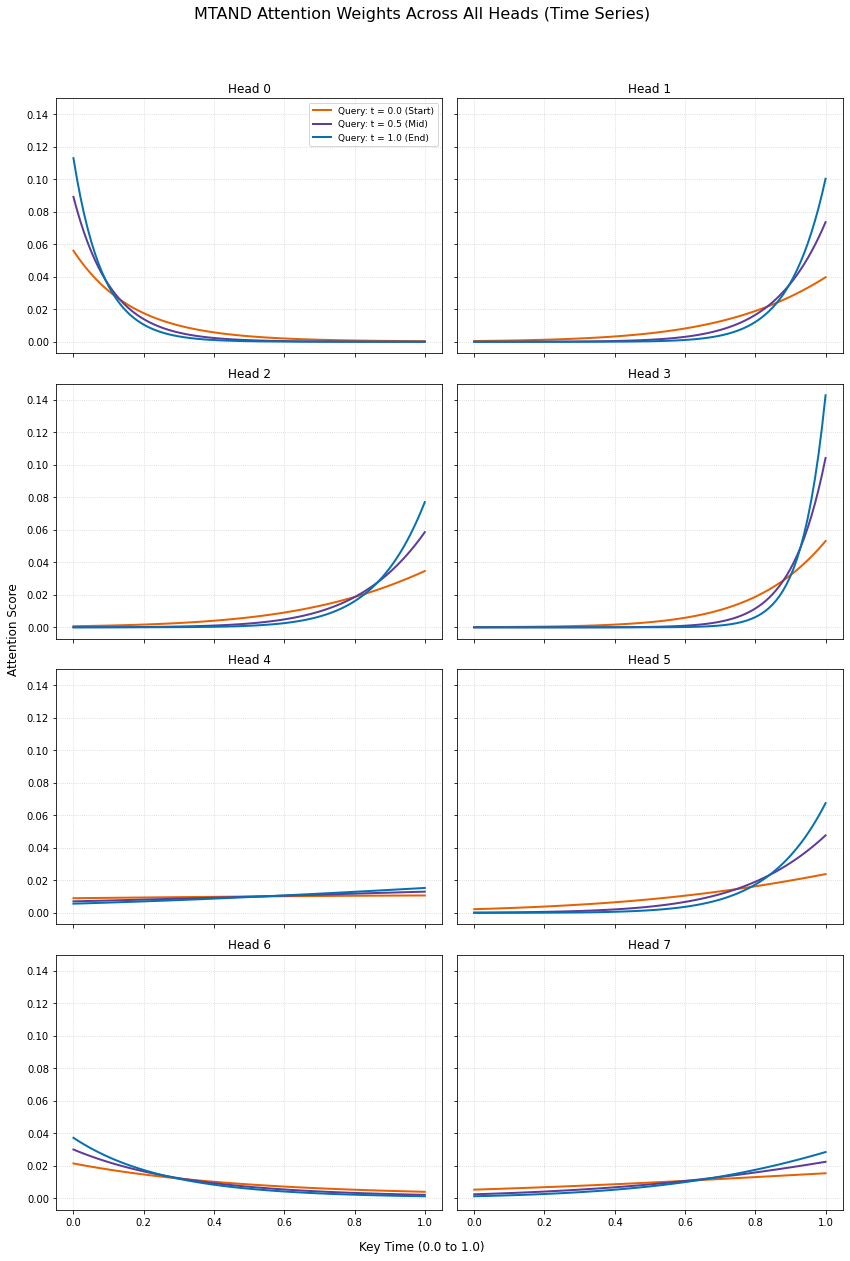

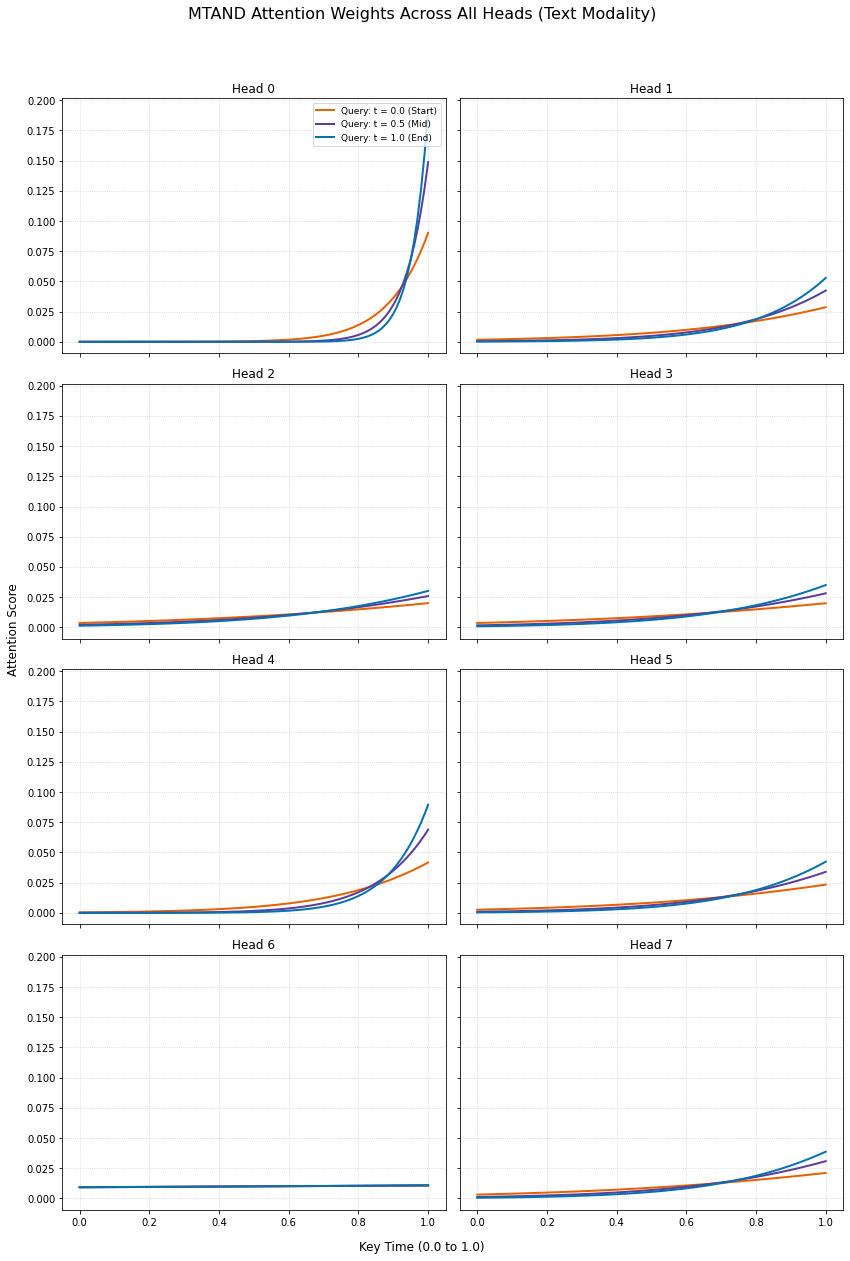

In [38]:
accelerator = Accelerator(cpu=args.cpu)

device = accelerator.device
os.makedirs(args.output_dir, exist_ok=True)

make_save_dir(args)

model = MULTCrossModel(args=args, device=device, orig_d_ts=30, orig_reg_d_ts=60, orig_d_txt=768, ts_seq_num=args.tt_max, text_seq_num=args.num_of_notes)
with open(os.path.join(args.file_path, f'scalers_{args.task}.pkl'), 'rb') as f:
    scalers = pickle.load(f)

model = accelerator.prepare(model)

rootdir = args.ck_file_path
seed = 1

for subdir, dirs, files in os.walk(rootdir):
    substr = subdir.split('/')[-1]
    if 'f1' not in substr:
        continue

    file = f'{seed}.pth.tar'
    file_path = os.path.join(subdir, file)
    print(file_path)
    checkpoint = torch.load(file_path, map_location=device)
    model.load_state_dict(checkpoint['network'])
    model.eval()

    with torch.no_grad():
        # 1. 定義 100 個 Key 時間點 (0 到 1 均勻分佈)
        key_times = torch.linspace(0.0, 1.0, steps=100, device=device).unsqueeze(0) # [1, 100]
        times_np = key_times.squeeze(0).cpu().numpy()

        keys_emb = model.learn_time_embedding(key_times) # [1, 100, time_dim]
        
        # 提取各模態的 Key 轉換矩陣
        num_heads = args.num_heads
        embed_time = args.embed_time
        embed_time_k = embed_time // num_heads
        k_transformed_ts = model.time_attn_ts.linears[1](keys_emb).view(keys_emb.size(0), -1, num_heads, embed_time_k).transpose(1, 2) # [1, h, 100, h_dim]
        d_k_ts = k_transformed_ts.size(-1)

        has_text = hasattr(model, 'time_attn_text') and model.time_attn_text is not None
        if has_text:
            k_transformed_text = model.time_attn_text.linears[1](keys_emb).view(keys_emb.size(0), -1, num_heads, embed_time_k).transpose(1, 2)
            d_k_text = k_transformed_text.size(-1)

        # 2. 定義三個想要測試的 Query 時間點
        queries = {
            't = 0.0 (Start)': torch.tensor([[0.0]], dtype=torch.float32, device=device),
            't = 0.5 (Mid)': torch.tensor([[0.5]], dtype=torch.float32, device=device),
            't = 1.0 (End)': torch.tensor([[1.0]], dtype=torch.float32, device=device)
        }

        # 設定色彩
        colors = {'t = 0.0 (Start)': '#E66101', 't = 0.5 (Mid)': '#5E3C99', 't = 1.0 (End)': '#0571B0'}
        os.makedirs(os.path.join(args.ck_file_path, 'images'), exist_ok=True)

        # 計算子圖的網格排列（假設 num_heads=4，會排成 2x2；若 num_heads=2，則排成 1x2）
        ncols = 2 if num_heads >= 2 else 1
        nrows = math.ceil(num_heads / ncols)

        # ====================================================
        # 繪製 1. 時間序列 (Time Series) 的 All Heads Plot
        # ====================================================
        fig_ts, axes_ts = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), sharex=True, sharey=True)
        # 將 axes 展平方便用索引處理 (處理單個子圖或多個子圖的情況)
        axes_ts = axes_ts.flatten() if num_heads > 1 else [axes_ts]

        for head in range(num_heads):
            ax = axes_ts[head]
            for label, q_time in queries.items():
                query_emb = model.learn_time_embedding(q_time)
                q_transformed = model.time_attn_ts.linears[0](query_emb).view(query_emb.size(0), -1, num_heads, embed_time_k).transpose(1, 2)
                scores = torch.matmul(q_transformed, k_transformed_ts.transpose(-2, -1)) / (d_k_ts ** 0.5)
                attention_weights = F.softmax(scores, dim=-1).squeeze(0).cpu().numpy() # [h, 1, 100]
                
                ax.plot(times_np, attention_weights[head, 0, :], label=f'Query: {label}', color=colors[label], linewidth=2)

            ax.set_title(f'Head {head}', fontsize=12)
            ax.grid(True, linestyle=':', alpha=0.6)
            if head == 0:  # 只在第一個子圖顯示 legend 避免畫面太亂
                ax.legend(loc='upper right', frameon=True, fontsize=9)

        # 設定整張大圖的標題與軸標籤
        fig_ts.suptitle('MTAND Attention Weights Across All Heads (Time Series)', fontsize=16, y=0.98)
        fig_ts.text(0.5, 0.02, 'Key Time (0.0 to 1.0)', ha='center', fontsize=12)
        fig_ts.text(0.02, 0.5, 'Attention Score', va='center', rotation='vertical', fontsize=12)
        
        plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
        save_path_ts = os.path.join(args.ck_file_path, 'images', 'mtand_attention_ts_all_heads.png')
        plt.savefig(save_path_ts, transparent=False, facecolor='white')
        plt.show()
        plt.close()

        # ====================================================
        # 繪製 2. 文字模態 (Text) 的 All Heads Plot (新增部分)
        # ====================================================
        if has_text:
            fig_txt, axes_txt = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), sharex=True, sharey=True)
            axes_txt = axes_txt.flatten() if num_heads > 1 else [axes_txt]

            for head in range(num_heads):
                ax = axes_txt[head]
                for label, q_time in queries.items():
                    query_emb = model.learn_time_embedding(q_time)
                    q_transformed = model.time_attn_text.linears[0](query_emb).view(query_emb.size(0), -1, num_heads, embed_time_k).transpose(1, 2)
                    
                    scores = torch.matmul(q_transformed, k_transformed_text.transpose(-2, -1)) / (d_k_text ** 0.5)
                    attention_weights = F.softmax(scores, dim=-1).squeeze(0).cpu().numpy()
                    
                    ax.plot(times_np, attention_weights[head, 0, :], label=f'Query: {label}', color=colors[label], linewidth=2)

                ax.set_title(f'Head {head}', fontsize=12)
                ax.grid(True, linestyle=':', alpha=0.6)
                if head == 0:
                    ax.legend(loc='upper right', frameon=True, fontsize=9)

            fig_txt.suptitle('MTAND Attention Weights Across All Heads (Text Modality)', fontsize=16, y=0.98)
            fig_txt.text(0.5, 0.02, 'Key Time (0.0 to 1.0)', ha='center', fontsize=12)
            fig_txt.text(0.02, 0.5, 'Attention Score', va='center', rotation='vertical', fontsize=12)
            
            plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
            save_path_text = os.path.join(args.ck_file_path, 'images', 'mtand_attention_text_all_heads.png')
            plt.savefig(save_path_text, transparent=False, facecolor='white')
            plt.show()
            plt.close()

# 視覺化時間特徵每個維度隨時間的變化

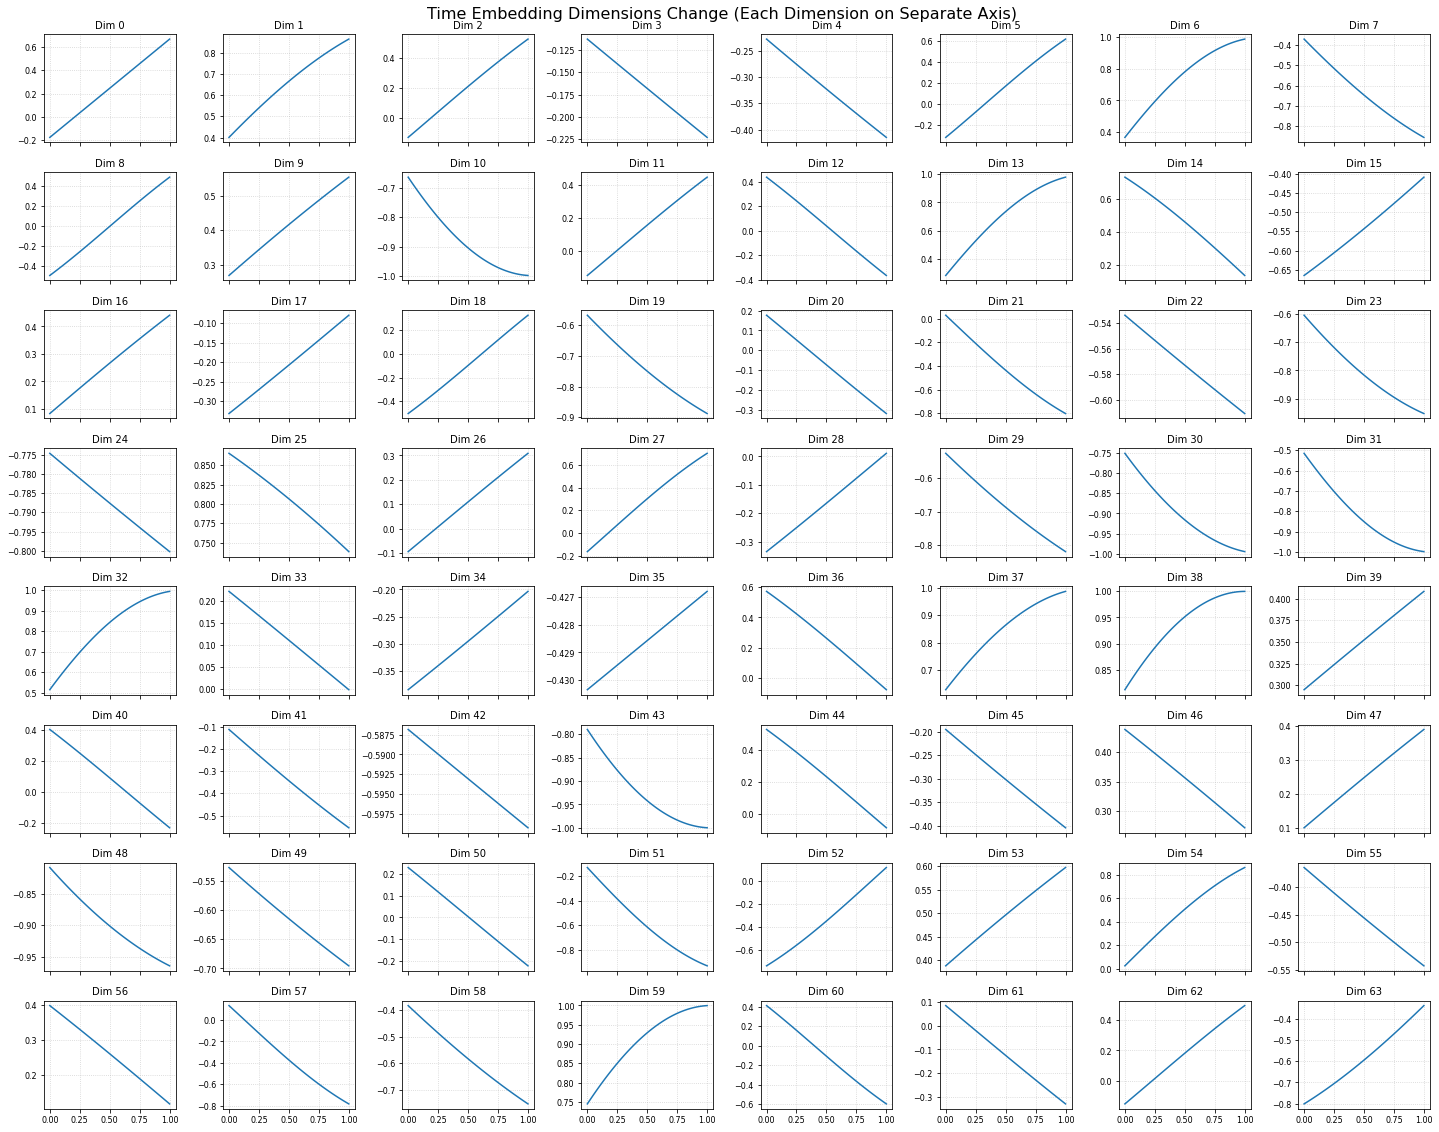

In [39]:
# 1. 建立 0 到 1 之間的時間序列
t_steps = torch.linspace(0, 1, 100).unsqueeze(0).to(device=next(model.parameters()).device)

# 2. 取得 Time Embedding 的輸出
with torch.no_grad():
    time_emb = model.learn_time_embedding(t_steps).cpu().numpy() # [1, 100, time_dim]
num_dims = time_emb.shape[-1]

# 3. 設定 8 行 8 列的子圖網格 (8x8 = 64)
cols = 8
rows = (num_dims + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 16), sharex=True)
axes = axes.flatten()  # 將多維子圖陣列展平，便於迴圈遍歷

t_np = t_steps[0].cpu().numpy()

# 4. 依序繪製每個維度的變化
for i in range(num_dims):
    ax = axes[i]
    ax.plot(t_np, time_emb[0, :, i], color='tab:blue', linewidth=1.5)
    ax.set_title(f'Dim {i}', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=8)

# 5. 如果有剩餘未使用的子圖則予以隱藏
for j in range(num_dims, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Time Embedding Dimensions Change (Each Dimension on Separate Axis)', fontsize=16)
plt.tight_layout()

# 儲存並顯示圖表
plt.savefig(os.path.join(rootdir, 'images', 'time_embedding_separate_axes.png'), transparent=False, facecolor='white')
plt.show()